In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\jaan\Downloads\Campaign_Data.csv")
df.head()

,CustID,status,Campaign_Exec_Date,Campaign_Channel
0,11111J11RREFG1VoGo1FejtGEVV88JtM,viewed,2019-05-28,Email
1,11111J11RREFG1VoGo1FejtGEVV88JtM,delivered,2019-05-29,Email
2,11111J11RREFG1VoGo1FejtGEVV88JtM,delivered,2019-05-30,Email
3,11111J11RREFG1VoGo1FejtGEVV88JtM,delivered,2019-06-03,Email
4,11111J11RREFG1VoGo1FejtGEVV88JtM,delivered,2019-06-04,Email


In [3]:
df.columns

Index(['CustID', 'status', 'Campaign_Exec_Date', 'Campaign_Channel'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10912592 entries, 0 to 10912591
Data columns (total 4 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   CustID              object
 1   status              object
 2   Campaign_Exec_Date  object
 3   Campaign_Channel    object
dtypes: object(4)
memory usage: 333.0+ MB


In [5]:
df.isna().sum().sum()

0

In [6]:
df.duplicated().sum()

0

In [7]:
df.Campaign_Channel.value_counts()

Email    10527383
SMS        385209
Name: Campaign_Channel, dtype: int64

In [8]:
print(df['Campaign_Channel'].value_counts()['Email'])

10527383


In [9]:
print(df['Campaign_Channel'].value_counts()['SMS'])

385209


In [10]:
df.describe()

,CustID,status,Campaign_Exec_Date,Campaign_Channel
count,10912592,10912592,10912592,10912592
unique,371216,4,525,2
top,E7H7JeJo118eH7J1FRFEtFA7GRMjojHH,viewed,2020-11-28,Email
freq,68,5697853,327960,10527383


In [11]:
df.sort_values(by=['Campaign_Exec_Date'])
df.head(5)

,CustID,status,Campaign_Exec_Date,Campaign_Channel
0,11111J11RREFG1VoGo1FejtGEVV88JtM,viewed,2019-05-28,Email
1,11111J11RREFG1VoGo1FejtGEVV88JtM,delivered,2019-05-29,Email
2,11111J11RREFG1VoGo1FejtGEVV88JtM,delivered,2019-05-30,Email
3,11111J11RREFG1VoGo1FejtGEVV88JtM,delivered,2019-06-03,Email
4,11111J11RREFG1VoGo1FejtGEVV88JtM,delivered,2019-06-04,Email


In [12]:
df.sort_values(by=['Campaign_Exec_Date'])
df.tail(5)

,CustID,status,Campaign_Exec_Date,Campaign_Channel
10912587,tttttoJHGe,viewed,2020-11-24,Email
10912588,tttttoJHGe,viewed,2020-11-25,Email
10912589,tttttoJHGe,viewed,2020-11-26,Email
10912590,tttttoJHGe,delivered,2020-11-27,Email
10912591,tttttoJHGe,delivered,2020-11-28,Email


In [13]:
df.status.value_counts()

viewed       5697853
delivered    5002558
click         170190
clicked        41991
Name: status, dtype: int64

# Camapaign data : The campaign consists of two modes of channels i.e email and sms in that majority of veiwership came through the emails compared to sms, there were 10912592 customer ids and 525 unique form dates where campaign runned.

In [14]:
df1 = pd.read_csv(r"C:\Users\jaan\Downloads\Customer_Master_Data.csv", dtype='unicode')
df1

,CustID,Gender,Marital_Status,Pincode,State
0,7teAttAeH,NaN,NaN,678506,Kerala
1,7t8tJJHt7,NaN,NaN,770001,Odisha
2,787t17tJt,NaN,NaN,245101,Uttar Pradesh
3,787ttJtHH,NaN,NaN,673008,Kerala
4,7878HHoHo,NaN,NaN,501510,Telangana
...,...,...,...,...,...
502116,EEEMVj1EAEH7M7eMAGAAG7H1MGHG1tJH,Male,NaN,141010,Punjab
502117,EEEMEoAMFtMHFo7jR8HAAMRV1oeREe1F,Female,Married,560059,Karnataka
502118,EEEEoREMHejJJjoEoReGRJ1Fe771ERGJ,Male,NaN,560085,Karnataka
502119,EEEE81e8oHt7HAFGjt8M81MGRM8JjVtj,Male,NaN,411007,Maharashtra


In [15]:
df1.head()

,CustID,Gender,Marital_Status,Pincode,State
0,7teAttAeH,NaN,NaN,678506,Kerala
1,7t8tJJHt7,NaN,NaN,770001,Odisha
2,787t17tJt,NaN,NaN,245101,Uttar Pradesh
3,787ttJtHH,NaN,NaN,673008,Kerala
4,7878HHoHo,NaN,NaN,501510,Telangana


In [16]:
df1.isna().sum()

CustID                 0
Gender            137654
Marital_Status    434126
Pincode             9872
State               9940
dtype: int64

In [17]:
df1.dropna(subset = ['Gender', 'Marital_Status','Pincode', 'State'], inplace= True)
df1.head()

,CustID,Gender,Marital_Status,Pincode,State
15,eeeeA1ReJFJjM1ARoFtJjttEe8oHoF7j,Female,Unmarried,110049,Delhi
26,eee7RAR71oGHAEAGMVHFVjjGAt78ooHe,Female,Unmarried,400612,Maharashtra
27,eee1e8FVFejeMe7RVMoFVJMGeEeV8AeJ,Female,Unmarried,700021,West Bengal
40,eeeoJ7t1Ej1oeGVo8M8781M8o178AMJ1,Female,Unmarried,560077,Karnataka
44,eeeojjVtjtGH1FE8t8j77EjoM7toVVFM,Female,Unmarried,122011,Haryana


In [18]:
df1.isna().sum()

CustID            0
Gender            0
Marital_Status    0
Pincode           0
State             0
dtype: int64

In [19]:
df1.duplicated().sum()

0

In [20]:
df1.isna().all()

CustID            False
Gender            False
Marital_Status    False
Pincode           False
State             False
dtype: bool

In [21]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 67523 entries, 15 to 502117
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustID          67523 non-null  object
 1   Gender          67523 non-null  object
 2   Marital_Status  67523 non-null  object
 3   Pincode         67523 non-null  object
 4   State           67523 non-null  object
dtypes: object(5)
memory usage: 3.1+ MB


In [22]:
df1.columns

Index(['CustID', 'Gender', 'Marital_Status', 'Pincode', 'State'], dtype='object')

In [23]:
df1.describe()

,CustID,Gender,Marital_Status,Pincode,State
count,67523,67523,67523,67523,67523
unique,67523,3,2,3217,35
top,eeeeA1ReJFJjM1ARoFtJjttEe8oHoF7j,Female,Unmarried,122001,Maharashtra
freq,1,60131,44980,1432,20653


In [24]:
df2 = pd.read_csv(r'C:\Users\jaan\Downloads\Customer_Transaction_Data.csv')
df2.head()

,CustID,ItemDesc,MerchCategoryDescription,MerchClassDescription,MerchGroupDescription,SaleValue,OrderedQuantity,OrderDate,ReturnFlag,SalesChannelCode,Ecom_BnM_Indicator,StoreID,StoreCode,StoreCity,StoreState,StorePincode
0,JFRGRFjeEJVG8RJF8R1Foj8AJJ7Et8oH,APPLE PROTECTION PLAN MACBOOK PRO,APPLE PROTECTION PLAN MACBOOK PRO,Mobile Computing,Computers Peripherals,-25398.00,-1,2019-01-01,NaN,RS,B&M,83.0,A129,Pune,Maharashtra,411014
1,JFRGRFjeEJVG8RJF8R1Foj8AJJ7Et8oH,MacBook Pro 16 2.6GH i7 9G 16GB 512GB SG,MacBook Pro 16 2.6GH i7 9G 16GB 512GB SG,Mobile Computing,Computers Peripherals,-193703.10,-1,2019-01-01,NaN,RS,B&M,83.0,A129,Pune,Maharashtra,411014
2,V1AG7tA7E1tMVjt7tVH7JARR11AVotet,Samsung Galaxy A70 S 6GB White,Samsung Galaxy A70 S 6GB White,Smart Phones (OS Based),Communication,26518.98,1,2019-01-01,NaN,RS,B&M,79.0,A122,Ghaziabad,Delhi NCR,201001
3,V1AG7tA7E1tMVjt7tVH7JARR11AVotet,Wireless Earphones ITFIT Freebie Red,Wireless Earphones ITFIT Freebie Red,Free Gifts,Miscellaneous,0.00,1,2019-01-01,NaN,RS,B&M,79.0,A122,Ghaziabad,Delhi NCR,201001
4,tAEVH8jEG1Eoe1GE1JEojJetVtMGFjto,DELL New bag pack,DELL New bag pack,Mobile Computing,Computers Peripherals,-1120.98,-1,2019-01-01,NaN,RS,B&M,8.0,A010,Surat,Gujarat,395007


In [25]:
df2.isna().sum()

CustID                            0
ItemDesc                       9866
MerchCategoryDescription       9866
MerchClassDescription         11835
MerchGroupDescription         11835
SaleValue                         9
OrderedQuantity                   0
OrderDate                         0
ReturnFlag                  1548154
SalesChannelCode                  0
Ecom_BnM_Indicator                0
StoreID                          19
StoreCode                         3
StoreCity                    125124
StoreState                   182927
StorePincode                 182927
dtype: int64

In [26]:
df2.dropna(inplace=True)

In [27]:
df2.isnull().sum()

CustID                      0
ItemDesc                    0
MerchCategoryDescription    0
MerchClassDescription       0
MerchGroupDescription       0
SaleValue                   0
OrderedQuantity             0
OrderDate                   0
ReturnFlag                  0
SalesChannelCode            0
Ecom_BnM_Indicator          0
StoreID                     0
StoreCode                   0
StoreCity                   0
StoreState                  0
StorePincode                0
dtype: int64

In [28]:
df2.duplicated().sum()

4563

In [29]:
df2.drop_duplicates(inplace=True)

In [30]:
df2.duplicated().sum()

0

In [31]:
df2.head()

,CustID,ItemDesc,MerchCategoryDescription,MerchClassDescription,MerchGroupDescription,SaleValue,OrderedQuantity,OrderDate,ReturnFlag,SalesChannelCode,Ecom_BnM_Indicator,StoreID,StoreCode,StoreCity,StoreState,StorePincode
3807,j1MEeoF1EREEteeeEGGHjoAM87FJG1jG,HAIER REF SBS 531L HRB550CG CH GL,HAIER REF SBS 531L HRB550CG CH GL,Refrigerators,Large Appliances,-64149.330,-1,2019-12-11,F,EA,B&M,163.0,A215,Nashik,Maharashtra,422011
4930,Ze1q781e7eeGete,Eleon Spk BT Megh ELER2103 Blk,Eleon Spk BT Megh ELER2103 Blk,Portable BT Speakers/MP3 Players,Entertainment,-1213.800,-1,2020-03-01,P,RS,B&M,142.0,A192,Bhopal,Madhya Pradesh,462004
4936,Ze1qeJJeoeotHJA,CROMA LED HRD 32in Basic EL7369 3Yr Wrty,CROMA LED HRD 32in Basic EL7369 3Yr Wrty,TV LCD,Entertainment,-14219.514,-1,2020-03-02,P,RS,B&M,35.0,A044,New Delhi,Delhi NCR,110027
4974,Ze1lgy7e7Je7177,RD PLAST - AC Brackets(2 Yr Wrnty),RD PLAST - AC Brackets(2 Yr Wrnty),Air Conditioners,Large Appliances,-1017.960,-2,2020-03-05,P,RS,B&M,101.0,A148,Hyderabad,Telangana,500014
4986,oHVRVeJGFEo1ReeMtEJttFVFRJGEetej,VOLTAS WD Minimagic Pure R,VOLTAS WD Minimagic Pure R,Water Purifiers,Small Appliances,-8872.980,-1,2020-03-06,P,RS,B&M,22.0,A028,Hyderabad,Telangana,500033


In [32]:
df2.describe()

,SaleValue,OrderedQuantity,StoreID
count,6.147800e+04,61478.000000,61478.000000
mean,-1.905724e+04,-1.029425,144.423875
std,3.005625e+04,1.238430,167.737564
min,-1.218900e+06,-190.000000,1.000000
25%,-2.845777e+04,-1.000000,43.000000
50%,-5.098980e+03,-1.000000,97.000000
75%,-1.120980e+03,-1.000000,157.000000
max,4.080000e+03,0.000000,754.000000


In [33]:
merged_data = pd.merge(df, df1, on='CustID', how='inner')

In [34]:
final_data = pd.merge(merged_data, df2, on='CustID', how='inner')

In [35]:
merged_data.isna().sum()

CustID                0
status                0
Campaign_Exec_Date    0
Campaign_Channel      0
Gender                0
Marital_Status        0
Pincode               0
State                 0
dtype: int64

In [36]:
merged_data.head()

,CustID,status,Campaign_Exec_Date,Campaign_Channel,Gender,Marital_Status,Pincode,State
0,1118FFMGVt1eRoF7jFeA7Ft1GFFHFAEG,delivered,2019-12-25,SMS,Female,Married,403507,Goa
1,1118FFMGVt1eRoF7jFeA7Ft1GFFHFAEG,clicked,2020-11-25,SMS,Female,Married,403507,Goa
2,1118FFMGVt1eRoF7jFeA7Ft1GFFHFAEG,delivered,2020-11-28,SMS,Female,Married,403507,Goa
3,1118jEVVjee8FJF118JAARt8Ejoj1toj,delivered,2019-12-24,SMS,Female,Married,411007,Maharashtra
4,1118jEVVjee8FJF118JAARt8Ejoj1toj,delivered,2020-11-28,SMS,Female,Married,411007,Maharashtra


In [37]:
merged_data.duplicated().sum()

0

In [38]:
final_data.head(5)

,CustID,status,Campaign_Exec_Date,Campaign_Channel,Gender,Marital_Status,Pincode,State,ItemDesc,MerchCategoryDescription,...,OrderedQuantity,OrderDate,ReturnFlag,SalesChannelCode,Ecom_BnM_Indicator,StoreID,StoreCode,StoreCity,StoreState,StorePincode
0,1118jEVVjee8FJF118JAARt8Ejoj1toj,delivered,2019-12-24,SMS,Female,Married,411007,Maharashtra,boAt Airdopes 441 TWS Active Black RTL (HSN-85...,boAt Airdopes 441 TWS Active Black RTL (HSN-85...,...,-1,2021-04-10,P,RS,B&M,9.0,A011,Pune,Maharashtra,411007
1,1118jEVVjee8FJF118JAARt8Ejoj1toj,delivered,2020-11-28,SMS,Female,Married,411007,Maharashtra,boAt Airdopes 441 TWS Active Black RTL (HSN-85...,boAt Airdopes 441 TWS Active Black RTL (HSN-85...,...,-1,2021-04-10,P,RS,B&M,9.0,A011,Pune,Maharashtra,411007
2,1177tRtFA78oeRjHJj7JFRJAVG1GMtGH,viewed,2019-05-28,Email,Female,Unmarried,382424,Gujarat,Fire-Boltt Ninja Pro BSW011 Black,Fire-Boltt Ninja Pro BSW011 Black,...,-1,2021-03-29,P,RS,B&M,96.0,A143,Ahmedabad,Gujarat,380005
3,1177tRtFA78oeRjHJj7JFRJAVG1GMtGH,delivered,2019-05-29,Email,Female,Unmarried,382424,Gujarat,Fire-Boltt Ninja Pro BSW011 Black,Fire-Boltt Ninja Pro BSW011 Black,...,-1,2021-03-29,P,RS,B&M,96.0,A143,Ahmedabad,Gujarat,380005
4,1177tRtFA78oeRjHJj7JFRJAVG1GMtGH,delivered,2019-05-30,Email,Female,Unmarried,382424,Gujarat,Fire-Boltt Ninja Pro BSW011 Black,Fire-Boltt Ninja Pro BSW011 Black,...,-1,2021-03-29,P,RS,B&M,96.0,A143,Ahmedabad,Gujarat,380005


In [39]:
final_data.duplicated().sum()

0

In [40]:
final_data.isnull().sum()

CustID                      0
status                      0
Campaign_Exec_Date          0
Campaign_Channel            0
Gender                      0
Marital_Status              0
Pincode                     0
State                       0
ItemDesc                    0
MerchCategoryDescription    0
MerchClassDescription       0
MerchGroupDescription       0
SaleValue                   0
OrderedQuantity             0
OrderDate                   0
ReturnFlag                  0
SalesChannelCode            0
Ecom_BnM_Indicator          0
StoreID                     0
StoreCode                   0
StoreCity                   0
StoreState                  0
StorePincode                0
dtype: int64

In [41]:
final_data.shape

(154701, 23)

In [42]:
final_data.columns

Index(['CustID', 'status', 'Campaign_Exec_Date', 'Campaign_Channel', 'Gender',
       'Marital_Status', 'Pincode', 'State', 'ItemDesc',
       'MerchCategoryDescription', 'MerchClassDescription',
       'MerchGroupDescription', 'SaleValue', 'OrderedQuantity', 'OrderDate',
       'ReturnFlag', 'SalesChannelCode', 'Ecom_BnM_Indicator', 'StoreID',
       'StoreCode', 'StoreCity', 'StoreState', 'StorePincode'],
      dtype='object')

In [43]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 154701 entries, 0 to 154700
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CustID                    154701 non-null  object 
 1   status                    154701 non-null  object 
 2   Campaign_Exec_Date        154701 non-null  object 
 3   Campaign_Channel          154701 non-null  object 
 4   Gender                    154701 non-null  object 
 5   Marital_Status            154701 non-null  object 
 6   Pincode                   154701 non-null  object 
 7   State                     154701 non-null  object 
 8   ItemDesc                  154701 non-null  object 
 9   MerchCategoryDescription  154701 non-null  object 
 10  MerchClassDescription     154701 non-null  object 
 11  MerchGroupDescription     154701 non-null  object 
 12  SaleValue                 154701 non-null  float64
 13  OrderedQuantity           154701 non-null  i

In [44]:
final_data.columns

Index(['CustID', 'status', 'Campaign_Exec_Date', 'Campaign_Channel', 'Gender',
       'Marital_Status', 'Pincode', 'State', 'ItemDesc',
       'MerchCategoryDescription', 'MerchClassDescription',
       'MerchGroupDescription', 'SaleValue', 'OrderedQuantity', 'OrderDate',
       'ReturnFlag', 'SalesChannelCode', 'Ecom_BnM_Indicator', 'StoreID',
       'StoreCode', 'StoreCity', 'StoreState', 'StorePincode'],
      dtype='object')

In [45]:
to_drop = ['Pincode','Marital_Status','StoreID','StoreCode']
final_data.drop(to_drop, inplace=True, axis=1)

In [46]:
final_data.head(5)

,CustID,status,Campaign_Exec_Date,Campaign_Channel,Gender,State,ItemDesc,MerchCategoryDescription,MerchClassDescription,MerchGroupDescription,SaleValue,OrderedQuantity,OrderDate,ReturnFlag,SalesChannelCode,Ecom_BnM_Indicator,StoreCity,StoreState,StorePincode
0,1118jEVVjee8FJF118JAARt8Ejoj1toj,delivered,2019-12-24,SMS,Female,Maharashtra,boAt Airdopes 441 TWS Active Black RTL (HSN-85...,boAt Airdopes 441 TWS Active Black RTL (HSN-85...,Earphones/Headphones,Entertainment,-2548.98,-1,2021-04-10,P,RS,B&M,Pune,Maharashtra,411007
1,1118jEVVjee8FJF118JAARt8Ejoj1toj,delivered,2020-11-28,SMS,Female,Maharashtra,boAt Airdopes 441 TWS Active Black RTL (HSN-85...,boAt Airdopes 441 TWS Active Black RTL (HSN-85...,Earphones/Headphones,Entertainment,-2548.98,-1,2021-04-10,P,RS,B&M,Pune,Maharashtra,411007
2,1177tRtFA78oeRjHJj7JFRJAVG1GMtGH,viewed,2019-05-28,Email,Female,Gujarat,Fire-Boltt Ninja Pro BSW011 Black,Fire-Boltt Ninja Pro BSW011 Black,Lifestyle & Wearables,Communication,-2038.98,-1,2021-03-29,P,RS,B&M,Ahmedabad,Gujarat,380005
3,1177tRtFA78oeRjHJj7JFRJAVG1GMtGH,delivered,2019-05-29,Email,Female,Gujarat,Fire-Boltt Ninja Pro BSW011 Black,Fire-Boltt Ninja Pro BSW011 Black,Lifestyle & Wearables,Communication,-2038.98,-1,2021-03-29,P,RS,B&M,Ahmedabad,Gujarat,380005
4,1177tRtFA78oeRjHJj7JFRJAVG1GMtGH,delivered,2019-05-30,Email,Female,Gujarat,Fire-Boltt Ninja Pro BSW011 Black,Fire-Boltt Ninja Pro BSW011 Black,Lifestyle & Wearables,Communication,-2038.98,-1,2021-03-29,P,RS,B&M,Ahmedabad,Gujarat,380005


In [47]:
final_data['Transaction_Date'] = pd.to_datetime(final_data['OrderDate'])

In [48]:
final_data['Campaign_End_Date'] = pd.to_datetime(final_data['Campaign_Exec_Date']) + pd.DateOffset(months=1)

In [49]:
final_data['Campaign_Outcome'] = (final_data['Transaction_Date'] <= final_data['Campaign_End_Date']).astype(int)

In [50]:
final_data.columns

Index(['CustID', 'status', 'Campaign_Exec_Date', 'Campaign_Channel', 'Gender',
       'State', 'ItemDesc', 'MerchCategoryDescription',
       'MerchClassDescription', 'MerchGroupDescription', 'SaleValue',
       'OrderedQuantity', 'OrderDate', 'ReturnFlag', 'SalesChannelCode',
       'Ecom_BnM_Indicator', 'StoreCity', 'StoreState', 'StorePincode',
       'Transaction_Date', 'Campaign_End_Date', 'Campaign_Outcome'],
      dtype='object')

In [51]:
final_data.tail()

,CustID,status,Campaign_Exec_Date,Campaign_Channel,Gender,State,ItemDesc,MerchCategoryDescription,MerchClassDescription,MerchGroupDescription,...,OrderDate,ReturnFlag,SalesChannelCode,Ecom_BnM_Indicator,StoreCity,StoreState,StorePincode,Transaction_Date,Campaign_End_Date,Campaign_Outcome
154696,tttoGGEtAjtJEJJM8E7tj8RVJRAGtete,viewed,2019-10-16,Email,Female,Maharashtra,Elica Cooktop 694 CTVT (SLMLINE SPF SE),Elica Cooktop 694 CTVT (SLMLINE SPF SE),Cookware,Small Appliances,...,2021-10-08,P,RS,B&M,Mumbai,Maharashtra,400067,2021-10-08,2019-11-16,0
154697,tttoGGEtAjtJEJJM8E7tj8RVJRAGtete,delivered,2019-12-25,SMS,Female,Maharashtra,Elica Cooktop 694 CTVT (SLMLINE SPF SE),Elica Cooktop 694 CTVT (SLMLINE SPF SE),Cookware,Small Appliances,...,2021-10-08,P,RS,B&M,Mumbai,Maharashtra,400067,2021-10-08,2020-01-25,0
154698,tttoGGEtAjtJEJJM8E7tj8RVJRAGtete,delivered,2019-12-30,Email,Female,Maharashtra,Elica Cooktop 694 CTVT (SLMLINE SPF SE),Elica Cooktop 694 CTVT (SLMLINE SPF SE),Cookware,Small Appliances,...,2021-10-08,P,RS,B&M,Mumbai,Maharashtra,400067,2021-10-08,2020-01-30,0
154699,tttoGGEtAjtJEJJM8E7tj8RVJRAGtete,viewed,2020-06-04,Email,Female,Maharashtra,Elica Cooktop 694 CTVT (SLMLINE SPF SE),Elica Cooktop 694 CTVT (SLMLINE SPF SE),Cookware,Small Appliances,...,2021-10-08,P,RS,B&M,Mumbai,Maharashtra,400067,2021-10-08,2020-07-04,0
154700,tttoGGEtAjtJEJJM8E7tj8RVJRAGtete,delivered,2020-11-28,SMS,Female,Maharashtra,Elica Cooktop 694 CTVT (SLMLINE SPF SE),Elica Cooktop 694 CTVT (SLMLINE SPF SE),Cookware,Small Appliances,...,2021-10-08,P,RS,B&M,Mumbai,Maharashtra,400067,2021-10-08,2020-12-28,0


In [52]:
final_data.duplicated().sum()

0

In [53]:
final_data.isna().sum()

CustID                      0
status                      0
Campaign_Exec_Date          0
Campaign_Channel            0
Gender                      0
State                       0
ItemDesc                    0
MerchCategoryDescription    0
MerchClassDescription       0
MerchGroupDescription       0
SaleValue                   0
OrderedQuantity             0
OrderDate                   0
ReturnFlag                  0
SalesChannelCode            0
Ecom_BnM_Indicator          0
StoreCity                   0
StoreState                  0
StorePincode                0
Transaction_Date            0
Campaign_End_Date           0
Campaign_Outcome            0
dtype: int64

In [54]:
final_data = pd.get_dummies(final_data)

In [55]:
final_data.head(5)

,SaleValue,OrderedQuantity,Transaction_Date,Campaign_End_Date,Campaign_Outcome,CustID_1118jEVVjee8FJF118JAARt8Ejoj1toj,CustID_1177tRtFA78oeRjHJj7JFRJAVG1GMtGH,CustID_1178oHjF8VAojA1J1RjVG7VFRjAEAFMR,CustID_11AREV1jEF8GojHRJ8G1H877tGV8AGEE,CustID_11EFjJHeHEF1GMG1V1e1RE1e7eVVeVj7,...,StorePincode_700055,StorePincode_700091,StorePincode_700099,StorePincode_700124,StorePincode_700156,StorePincode_700157,StorePincode_713304,StorePincode_751022,StorePincode_826004,StorePincode_831001
0,-2548.98,-1,2021-04-10,2020-01-24,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-2548.98,-1,2021-04-10,2020-12-28,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-2038.98,-1,2021-03-29,2019-06-28,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-2038.98,-1,2021-03-29,2019-06-29,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-2038.98,-1,2021-03-29,2019-06-30,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
#scaling the numerical data
scaler = StandardScaler()

In [57]:
final_data['SaleValue'] = scaler.fit_transform(final_data[['SaleValue']])

In [58]:
final_data.head(5)

,SaleValue,OrderedQuantity,Transaction_Date,Campaign_End_Date,Campaign_Outcome,CustID_1118jEVVjee8FJF118JAARt8Ejoj1toj,CustID_1177tRtFA78oeRjHJj7JFRJAVG1GMtGH,CustID_1178oHjF8VAojA1J1RjVG7VFRjAEAFMR,CustID_11AREV1jEF8GojHRJ8G1H877tGV8AGEE,CustID_11EFjJHeHEF1GMG1V1e1RE1e7eVVeVj7,...,StorePincode_700055,StorePincode_700091,StorePincode_700099,StorePincode_700124,StorePincode_700156,StorePincode_700157,StorePincode_713304,StorePincode_751022,StorePincode_826004,StorePincode_831001
0,0.523262,-1,2021-04-10,2020-01-24,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.523262,-1,2021-04-10,2020-12-28,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.541959,-1,2021-03-29,2019-06-28,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.541959,-1,2021-03-29,2019-06-29,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.541959,-1,2021-03-29,2019-06-30,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
final_data.columns

Index(['SaleValue', 'OrderedQuantity', 'Transaction_Date', 'Campaign_End_Date',
       'Campaign_Outcome', 'CustID_1118jEVVjee8FJF118JAARt8Ejoj1toj',
       'CustID_1177tRtFA78oeRjHJj7JFRJAVG1GMtGH',
       'CustID_1178oHjF8VAojA1J1RjVG7VFRjAEAFMR',
       'CustID_11AREV1jEF8GojHRJ8G1H877tGV8AGEE',
       'CustID_11EFjJHeHEF1GMG1V1e1RE1e7eVVeVj7',
       ...
       'StorePincode_700055', 'StorePincode_700091', 'StorePincode_700099',
       'StorePincode_700124', 'StorePincode_700156', 'StorePincode_700157',
       'StorePincode_713304', 'StorePincode_751022', 'StorePincode_826004',
       'StorePincode_831001'],
      dtype='object', length=12280)

In [60]:
X = final_data[['SaleValue', 'OrderedQuantity']]
y = final_data[['Campaign_Outcome']]

In [61]:
#splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
rf_model = RandomForestClassifier()

In [63]:
rf_model.fit(X_train, y_train.values.ravel())

RandomForestClassifier()

In [64]:
xgb_model = XGBClassifier()

In [65]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [66]:
rf_preds = rf_model.predict(X_test)
rf_conf_matrix = confusion_matrix(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_roc_auc = roc_auc_score(y_test, rf_preds)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_preds)

In [67]:
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Precision: 0.5171102661596958
Random Forest Recall: 0.05624483043837883
Random Forest Accuracy: 0.9221421414951035


In [68]:
xgb_preds = xgb_model.predict(X_test)
xgb_conf_matrix = confusion_matrix(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_roc_auc = roc_auc_score(y_test, xgb_preds)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_preds)

In [69]:
print("XGBoost Precision:", xgb_precision)
print("XGBoost Recall:", xgb_recall)
print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Precision: 0.5
XGBoost Recall: 0.0016542597187758478
XGBoost Accuracy: 0.9218512653113992


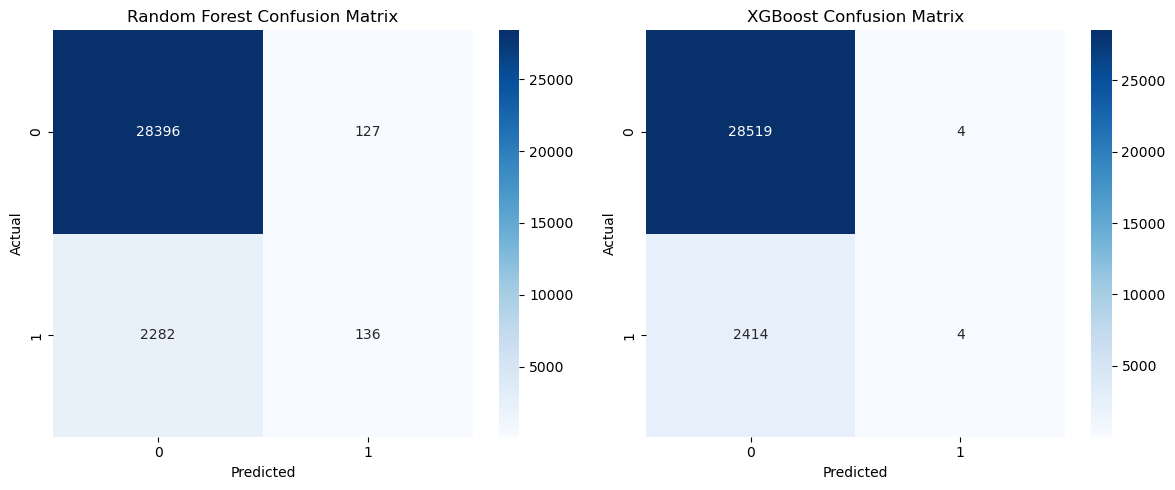

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(rf_conf_matrix, annot=True, cmap='Blues', fmt='g', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(xgb_conf_matrix, annot=True, cmap='Blues', fmt='g', ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

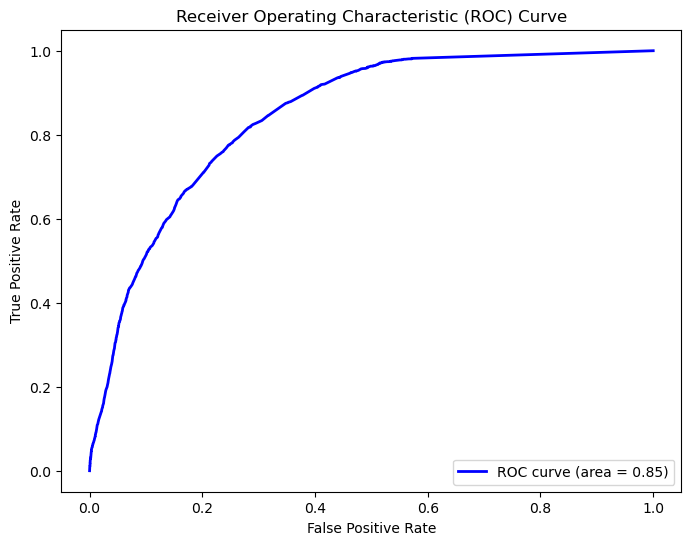

ROC AUC Score (Random Forest): 0.8455150918358313


In [71]:
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

#Calculate ROC AUC score
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

#Compute ROC curve and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_curve_rf = auc(fpr_rf, tpr_rf)

#Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_curve_rf)
#plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print("ROC AUC Score (Random Forest):", roc_auc_rf)

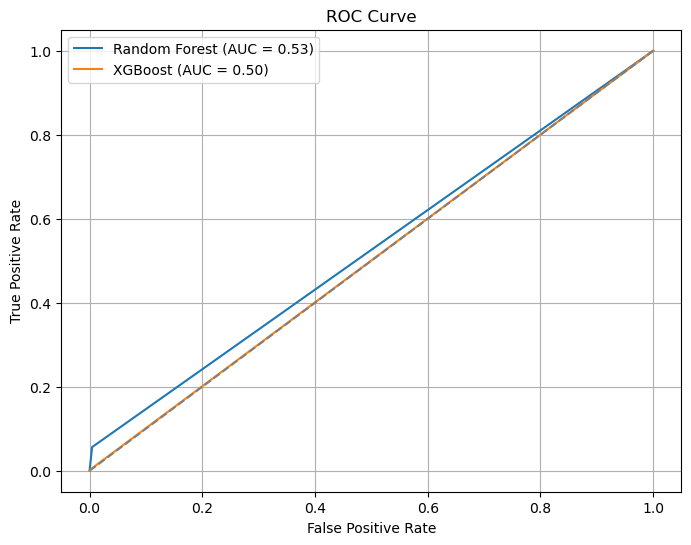

In [72]:
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_roc_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()